In [1]:
#クレジットカード会員について、A審査の申請をした後1年以内にB審査の申請もするかどうかの予測
#（A審査申請の段階で、申請内容から直近でB審査の申請をしてくるかどうかの予測）

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf

from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error

pd.options.display.max_columns = None

/Users/y-shibata/Downloads/aidev/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
#データの読み込み
#ある期間内にA審査の申請をしたカード会員の情報
#個人情報保護のため、カテゴリカルデータ含む諸データは事前に数値に変換済み
dataset=pd.read_csv("oaikouyou5.csv")

In [4]:
#「申請有無」は、A審査の申請後1年以内にB審査の申請をしたか否か（0:申請無,1:申請有）
dataset.head()

,No,性別,年代区分,住居状況区分,家族状況区分,家族人数区分,家族同居区分,年収区分,勤務形態区分,申込経路,申請理由,引上率,審査結果,申請有無
0,1,2,20代,5,2,1,2,2,2,3,1,1.0000,4,0
1,2,1,30代,5,2,1,1,2,2,3,5,1.0000,4,0
2,3,1,50代,1,1,4,1,9,2,3,0,1.5000,1,0
3,4,2,50代,1,2,1,2,4,2,3,18,1.2625,1,0
4,5,1,50代,3,1,2,2,4,2,3,10,1.6250,1,0


In [5]:
dataset.shape

(27252, 14)

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27252 entries, 0 to 27251
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      27252 non-null  int64  
 1   性別      27252 non-null  int64  
 2   年代区分    27252 non-null  object 
 3   住居状況区分  27252 non-null  int64  
 4   家族状況区分  27252 non-null  int64  
 5   家族人数区分  27252 non-null  int64  
 6   家族同居区分  27252 non-null  int64  
 7   年収区分    27252 non-null  int64  
 8   勤務形態区分  27252 non-null  int64  
 9   申込経路    27252 non-null  int64  
 10  申請理由    27252 non-null  int64  
 11  引上率     27252 non-null  float64
 12  審査結果    27252 non-null  int64  
 13  申請有無    27252 non-null  int64  
dtypes: float64(1), int64(12), object(1)
memory usage: 2.9+ MB


In [7]:
dataset.index.values

array([    0,     1,     2, ..., 27249, 27250, 27251])

In [8]:
dataset.columns.values

array(['No', '性別', '年代区分', '住居状況区分', '家族状況区分', '家族人数区分', '家族同居区分', '年収区分',
       '勤務形態区分', '申込経路', '申請理由', '引上率', '審査結果', '申請有無'], dtype=object)

In [9]:
dataset.describe()

,No,性別,住居状況区分,家族状況区分,家族人数区分,家族同居区分,年収区分,勤務形態区分,申込経路,申請理由,引上率,審査結果,申請有無
count,27252.000000,27252.000000,27252.000000,27252.000000,27252.000000,27252.000000,27252.000000,27252.000000,27252.000000,27252.000000,27252.000000,27252.000000,27252.000000
mean,14114.789887,1.532401,2.861038,1.477470,2.520035,1.366505,2.651659,3.622266,2.567224,4.718333,1.883979,1.770732,0.202921
std,8151.173145,0.498958,1.938248,0.510474,1.329472,1.252546,2.360179,2.722210,0.495469,4.739727,1.261175,1.334864,0.402181
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1.000000,1.000000,0.000000
25%,7051.750000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.090909,1.000000,0.000000
50%,14129.500000,2.000000,2.000000,1.000000,2.000000,1.000000,2.000000,2.000000,3.000000,3.000000,1.500000,1.000000,0.000000
75%,21156.250000,2.000000,5.000000,2.000000,4.000000,1.000000,4.000000,5.000000,3.000000,8.000000,2.250000,2.000000,0.000000
max,28269.000000,2.000000,7.000000,2.000000,9.000000,9.000000,9.000000,13.000000,3.000000,18.000000,31.000000,6.000000,1.000000


In [10]:
#分析に使用する列のみ抜き出しリネーム
dataset2=dataset[["性別","年代区分","年収区分","申請理由","引上率","審査結果","申請有無"]]
dataset2=dataset2.rename(columns={"性別":"sex","年代区分":"age","年収区分":"income","申請理由":"reason"\
                                ,"引上率":"rate","審査結果":"result","申請有無":"application"})

In [11]:
dataset2.head()

,sex,age,income,reason,rate,result,application
0,2,20代,2,1,1.0000,4,0
1,1,30代,2,5,1.0000,4,0
2,1,50代,9,0,1.5000,1,0
3,2,50代,4,18,1.2625,1,0
4,1,50代,4,10,1.6250,1,0


In [12]:
#意味を持たない数値区分についてカテゴリー変数に展開
dataset3=pd.get_dummies(data=dataset2,columns=["reason","result"])

In [13]:
dataset3=dataset3.replace({"age":{"10代":15,"20代":25,"30代":35,"40代":45,"50代":55,"60代":65,"70代":75,"80代":85,"90代":95}})

/var/folders/cx/jds9b3yn25bbfv_r9qtyy0y00000gp/T/ipykernel_2505/3193805759.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset3=dataset3.replace({"age":{"10代":15,"20代":25,"30代":35,"40代":45,"50代":55,"60代":65,"70代":75,"80代":85,"90代":95}})


In [14]:
dataset3.head()

,sex,age,income,rate,application,reason_0,reason_1,reason_2,reason_3,reason_4,reason_5,reason_6,reason_7,reason_8,reason_9,reason_10,reason_11,reason_12,reason_13,reason_14,reason_15,reason_16,reason_17,reason_18,result_1,result_2,result_4,result_6
0,2,25,2,1.0000,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,35,2,1.0000,0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,1,55,9,1.5000,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,2,55,4,1.2625,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False
4,1,55,4,1.6250,0,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False


In [15]:
from sklearn.preprocessing import MinMaxScaler
sc=MinMaxScaler()
dataset4=sc.fit_transform(dataset3)
dataset4

array([[1.        , 0.125     , 0.22222222, ..., 0.        , 1.        ,
        0.        ],
       [0.        , 0.25      , 0.22222222, ..., 0.        , 1.        ,
        0.        ],
       [0.        , 0.5       , 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [1.        , 0.375     , 0.66666667, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.25      , 0.22222222, ..., 0.        , 0.        ,
        0.        ],
       [1.        , 0.375     , 0.22222222, ..., 0.        , 0.        ,
        0.        ]])

In [16]:
dataset4=pd.DataFrame(data=dataset4,columns=dataset3.columns.values) 

In [17]:
dataset4.head()

,sex,age,income,rate,application,reason_0,reason_1,reason_2,reason_3,reason_4,reason_5,reason_6,reason_7,reason_8,reason_9,reason_10,reason_11,reason_12,reason_13,reason_14,reason_15,reason_16,reason_17,reason_18,result_1,result_2,result_4,result_6
0,1.0,0.125,0.222222,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.250,0.222222,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.500,1.000000,0.016667,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.0,0.500,0.444444,0.008750,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,0.0,0.500,0.444444,0.020833,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [18]:
Y=np.array(dataset4["application"])
X=np.array(dataset4.drop(columns="application"))

In [19]:
print("Y=",Y.shape,",X=",X.shape)

Y= (27252,) ,X= (27252, 27)


In [25]:
#アンダーサンプリング
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_resampled, Y_resampled = rus.fit_resample(X, Y)

ModuleNotFoundError: No module named 'imblearn'

In [20]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=0)
X_train,X_valid,Y_train,Y_valid=train_test_split(X_train,Y_train,test_size=0.3,random_state=0)

In [21]:
print("Y_train=",Y_train.shape,",X_train=",X_train.shape)
print("Y_valid=",Y_valid.shape,",X_valid=",X_valid.shape)
print("Y_test=",Y_test.shape,",X_test=",X_test.shape)

Y_train= (13353,) ,X_train= (13353, 27)
Y_valid= (5723,) ,X_valid= (5723, 27)
Y_test= (8176,) ,X_test= (8176, 27)


In [26]:
model=tf.keras.Sequential([
    tf.keras.Input(shape=(27,)),
    tf.keras.layers.Dense(32,activation="relu"),
    tf.keras.layers.Dense(32,activation="relu",kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dense(1,activation="sigmoid")
])
model.compile(optimizer="rmsprop",loss="binary_crossentropy",metrics=["accuracy"])

In [27]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,985 (7.75 KB)

 Trainable params: 1,985 (7.75 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
%%time
log=model.fit(X_train,Y_train,epochs=50,batch_size=32,verbose=True,
                callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss",
                                                            min_delta=0,patience=10,
                                                            verbose=1)],
                validation_data=(X_valid,Y_valid))

Epoch 1/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 658us/step - accuracy: 0.7895 - loss: 0.5224 - val_accuracy: 0.8059 - val_loss: 0.4799
Epoch 2/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 545us/step - accuracy: 0.7913 - loss: 0.4972 - val_accuracy: 0.8055 - val_loss: 0.4740
Epoch 3/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 495us/step - accuracy: 0.7915 - loss: 0.4934 - val_accuracy: 0.8055 - val_loss: 0.4720
Epoch 4/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 492us/step - accuracy: 0.7910 - loss: 0.4916 - val_accuracy: 0.8076 - val_loss: 0.4735
Epoch 5/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step - accuracy: 0.7908 - loss: 0.4904 - val_accuracy: 0.8073 - val_loss: 0.4699
Epoch 6/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 496us/step - accuracy: 0.7916 - loss: 0.4897 - val_accuracy: 0.8060 - val_loss: 0.4700
Epoch 7/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 495us/step - accuracy: 0.7909 - loss: 0.4889 - val_accuracy: 0.8062 - val_loss: 0.4687
Epoch 8/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 497us/step - accuracy: 0.7920 - loss: 0.4881 - 

Text(0, 0.5, 'crossentropy')

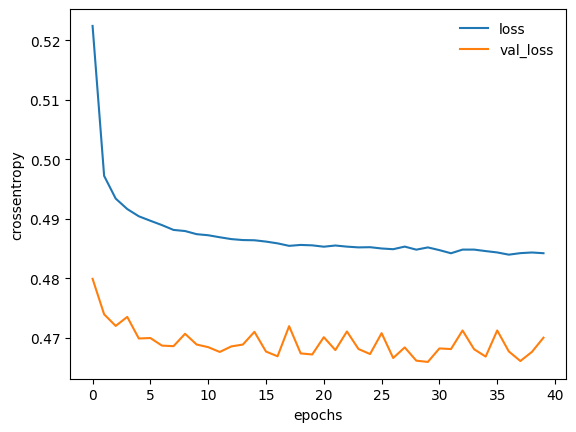

In [29]:
plt.plot(log.history["loss"],label="loss")
plt.plot(log.history["val_loss"],label="val_loss")
plt.legend(frameon=False)
plt.xlabel("epochs")
plt.ylabel("crossentropy")

In [30]:
Y_pred=model.predict(X_test)

256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 269us/step


In [31]:
Y_pred

array([[0.37470818],
       [0.11481678],
       [0.1855329 ],
       ...,
       [0.27537474],
       [0.18295813],
       [0.22571398]], dtype=float32)

In [53]:
Y_pred_cls=(Y_pred>0.5).astype("int32")
Y_pred_cls

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], dtype=int32)

In [54]:
Y_pred_=Y_pred_cls.reshape(-1)

In [55]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,Y_pred_))

              precision    recall  f1-score   support

         0.0       0.80      1.00      0.89      6550
         1.0       0.54      0.02      0.04      1626

    accuracy                           0.80      8176
   macro avg       0.67      0.51      0.47      8176
weighted avg       0.75      0.80      0.72      8176



In [ ]:
#閾値を変更
Y_pred_cls2=(Y_pred>0.4).astype("int32")
Y_pred_cls2

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], dtype=int32)

In [64]:
Y_pred_2=Y_pred_cls2.reshape(-1)

In [65]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,Y_pred_2))

              precision    recall  f1-score   support

         0.0       0.82      0.95      0.88      6550
         1.0       0.43      0.14      0.22      1626

    accuracy                           0.79      8176
   macro avg       0.62      0.55      0.55      8176
weighted avg       0.74      0.79      0.75      8176



In [ ]:
#アンダーサンプリング
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

ModuleNotFoundError: No module named 'imblearn'